Problem Statement -

    Businesses deal with customers who have all sorts of income levels and spending habits. It gets difficult to come up with marketing that actually works for everybody at the same time. 

    This project tries to use K Means clustering to sort customers into groups based on annual income and spending score. The idea seems to be that companies can get a clearer sense of who they are dealing with and maybe build better plans around that. 

    Some people might see the data one way while others look at it differently. It feels like the main goal is to make things more targeted but I am not totally sure how far the groups will go in practice.

Importing the Dependencies

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [71]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\hites\.cache\kagglehub\datasets\vjchoudhary7\customer-segmentation-tutorial-in-python\versions\1


In [72]:
df = pd.read_csv(path + "/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Data Cleaning

In [73]:
df.shape

(200, 5)

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [75]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [76]:
# No null value in any column. So we can proceed with the analysis.

EDA - Exploratory Data Analysis


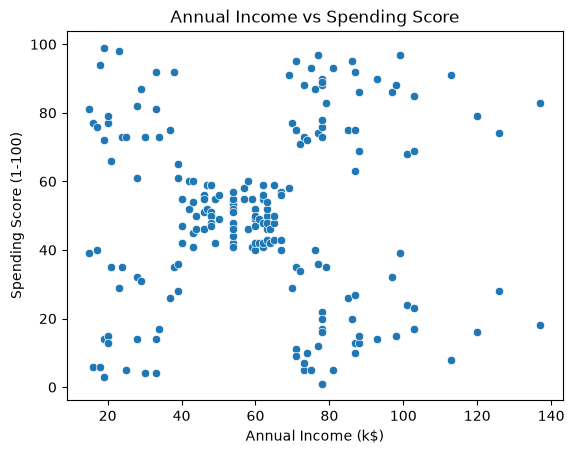

In [77]:
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)
plt.title('Annual Income vs Spending Score')
plt.show()

Feature Selection

    -> all the features are not needed for the clustering of the buyers so we do feature selection of only relevant features
    -> CustomerID, Gender, Age is an identifier it not helps to find customer behaviour 

In [78]:
df = df.drop(['CustomerID', 'Gender', 'Age'], axis=1)
df.head()   

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [79]:
# We do not need feature scaling as the features, Annual Income and Spending Score are already in the same range.

Choosing the optimal number of clusters using the elbow method:

In [80]:
wcss = []  # Within-Cluster Sum of Squares

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

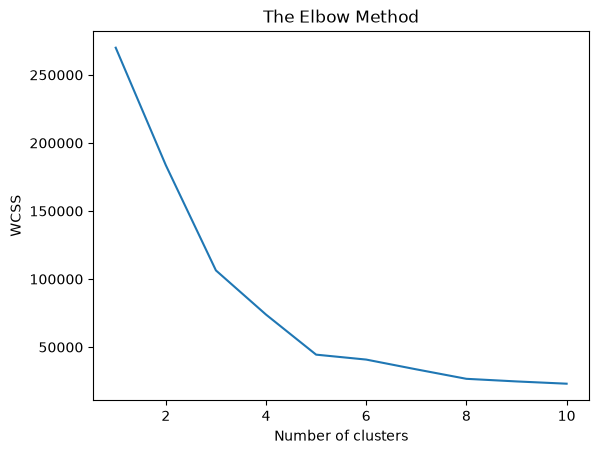

In [81]:
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

In [82]:
# By this we can choose the number of cluster to be 5. As the elbow is formed at 5.

Training the KMeans Algorithm

In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)

In [84]:
y_hat = kmeans.fit_predict(df)

df['Cluster'] = y_hat
df.head()

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,2
1,15,81,4
2,16,6,2
3,16,77,4
4,17,40,2


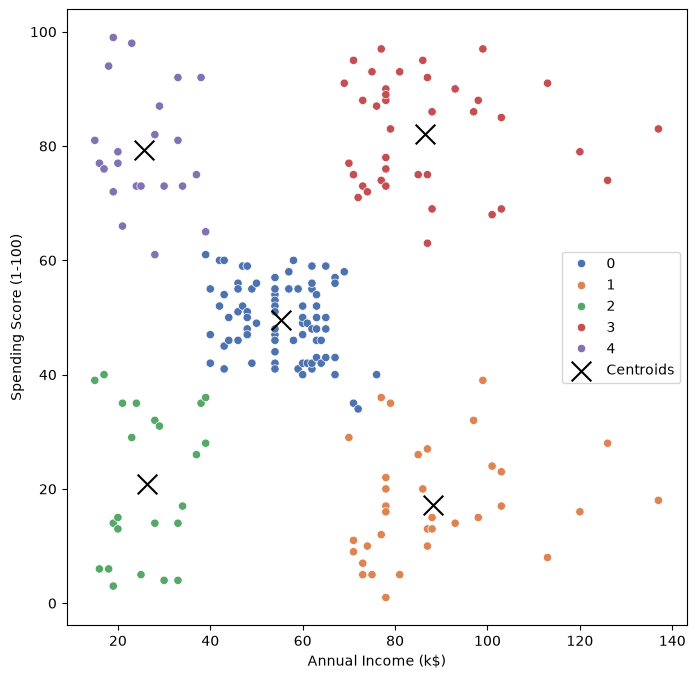

In [85]:
# Visualizing the clusters

plt.figure(figsize=(8, 8))
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], hue=df['Cluster'], palette='deep')
centroids = kmeans.cluster_centers_

plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=200, color='black', label='Centroids')
plt.legend()
plt.show()

In [86]:
df.groupby('Cluster').mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,88.200000,17.114286
2,26.304348,20.913043
3,86.538462,82.128205
4,25.727273,79.363636


    Cluster 0 → Average Customers

    Cluster 1 → High Income, Low Spending

    Cluster 2 → Low Income, Low Spending

    Cluster 3 → High Income, High Spending

    Cluster 4 → Low Income, High Spending



Business Strategies -

Cluster 1 — High Income, Low Spending (your biggest opportunity)

    They have the money but aren't spending it at your mall — meaning something is failing to convert their potential.

    -> Introduce premium/aspirational brands they might not know are here
    -> Use exclusivity marketing — invite them to VIP preview events, private sales

Cluster 3 — High Income, High Spending (your VIPs)

    These are your most valuable customers, so the priority is retention, not acquisition.

    -> Launch a premium loyalty/rewards program with exclusive perks
    -> Partner with luxury/premium brands to stock more high-end inventory

Cluster 4 — Low Income, High Spending (price-conscious enthusiasts)

    They're motivated shoppers but budget-constrained, so value perception matters most.

    -> Offer installment/EMI options or buy-now-pay-later schemes
    -> Bundle deals, combo offers, and loyalty points that stretch their spending power
    -> Affordable trendy brands rather than luxury lines

Cluster 2 — Low Income, Low Spending (low priority, low cost engagement)


    Don't over-invest here — focus on low-cost, high-reach tactics.

    ->Budget/discount store zones, clearance sections
    ->Seasonal or festival sales to drive occasional footfall
    -> Not a strategic priority for premium initiatives

Cluster 0 — Average Customers (the stable base)

    Maintain and gradually upsell.

    -> Cross-sell and upsell through bundling and recommendations
    -> Monitor for movement — some may shift toward Cluster 3/4 with the right nudges